In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


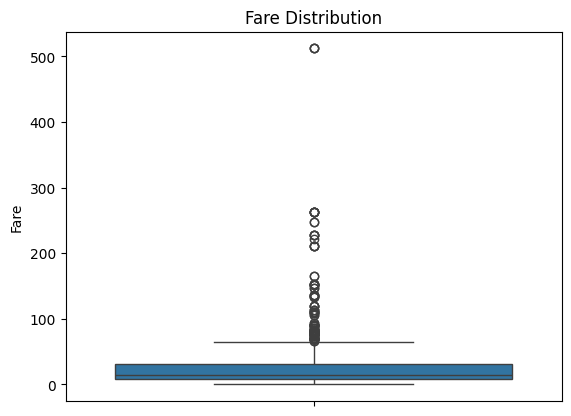

Fare skewness: 4.787316519674893
Age skewness: 0.38910778230082704


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

# Visualize outliers in Fare column
sns.boxplot(df["Fare"])
plt.title("Fare Distribution")
plt.show()

# Check skewness
print("Fare skewness:", df["Fare"].skew())
print("Age skewness:", df["Age"].skew())

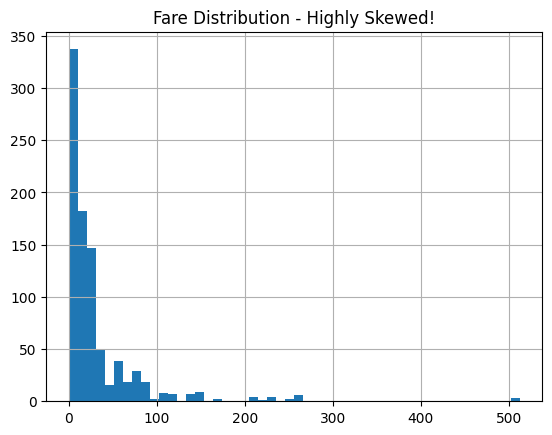

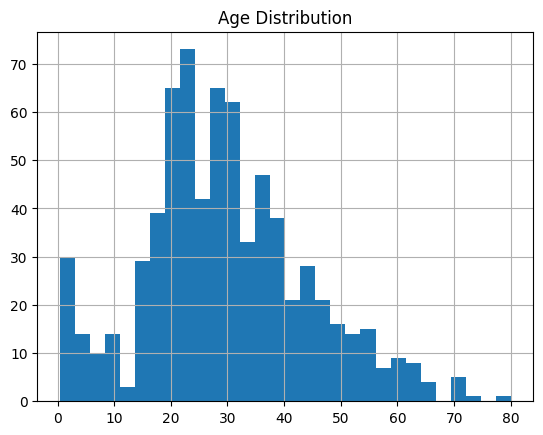

Fare skewness: 4.787316519674893
Age skewness: 0.38910778230082704


In [3]:
# Visualize skewness
df["Fare"].hist(bins=50)
plt.title("Fare Distribution - Highly Skewed!")
plt.show()

# Compare with Age
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.show()

# Print both skewness values
print("Fare skewness:", df["Fare"].skew())
print("Age skewness:", df["Age"].skew())

In [4]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

# Anything outside this range = outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

# Remove outliers
df_cleaned = df[(df["Fare"] >= lower) & (df["Fare"] <= upper)]
print("Before:", len(df))
print("After:", len(df_cleaned))

Lower bound: -26.724
Upper bound: 65.6344
Before: 891
After: 775


Fare skewness after log: 0.3949280095189306


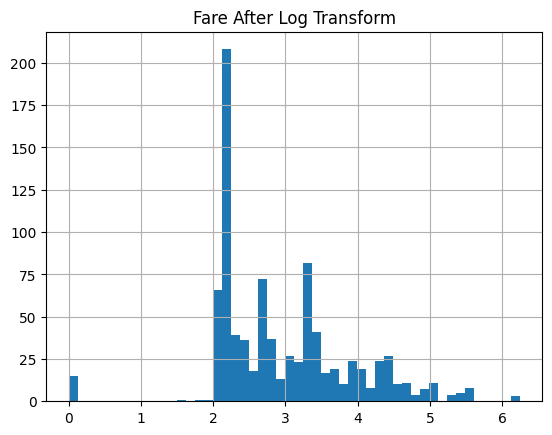

In [5]:
import numpy as np

df["Fare_log"] = np.log1p(df["Fare"])
print("Fare skewness after log:", df["Fare_log"].skew())

df["Fare_log"].hist(bins=50)
plt.title("Fare After Log Transform")
plt.show()